File: 0_3A_Aufgabe_1_M10.csv
Amplitude: 0.930787465899828, Omega: 3.2559678245958206, Delta: 0.10043301779141933, Phase: -1.0232439430311961, Offset: 0.03744447454963064


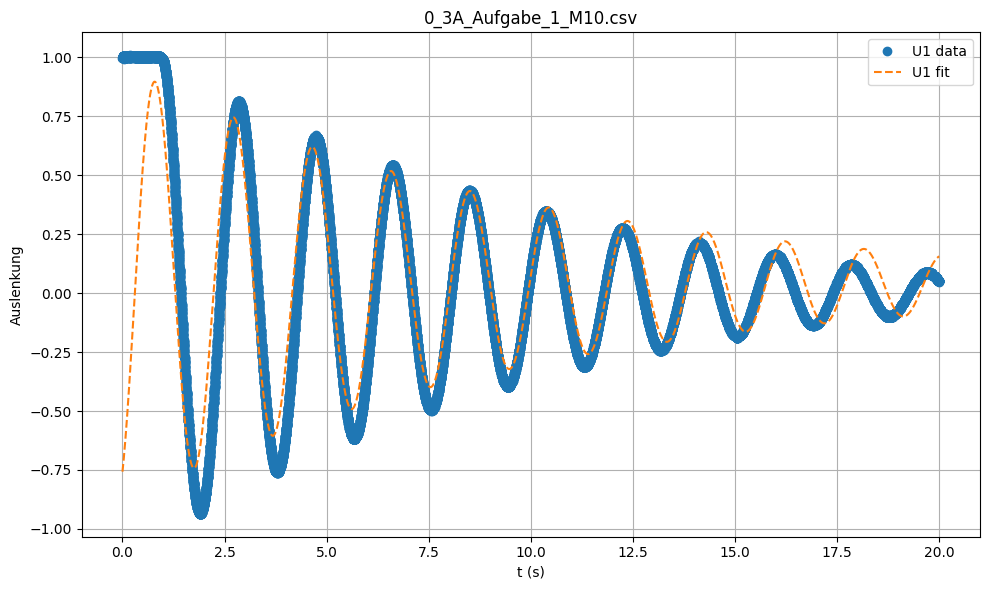

File: 0_4A_Aufgabe_1_M10.csv
Amplitude: 1.240920605261815, Omega: 3.1823893788939825, Delta: 0.22370614583898954, Phase: -0.3627001176054721, Offset: 0.019653645147242882


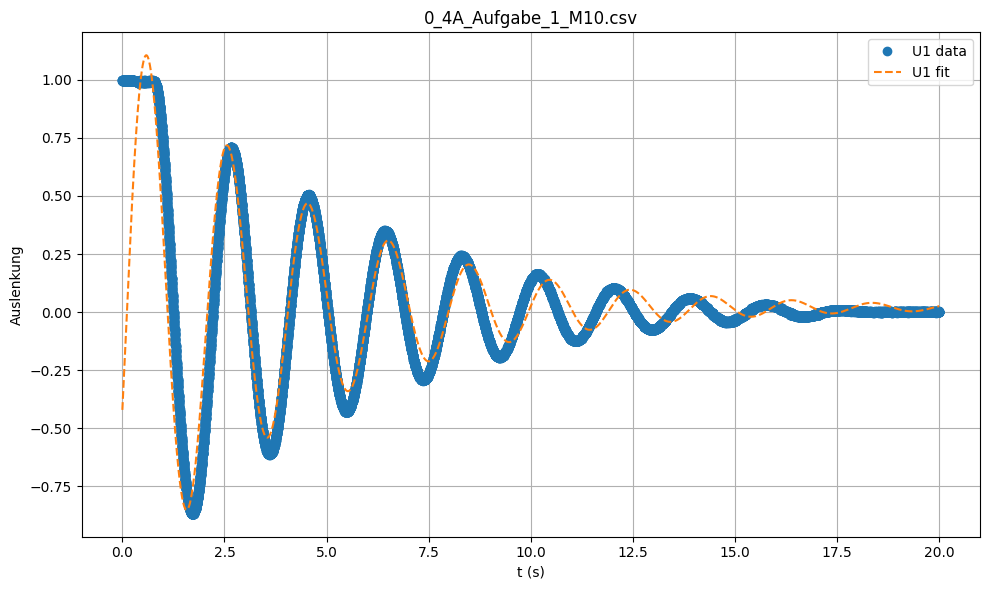

File: 0_5A_Aufgabe_1_M10.csv
Amplitude: 0.9945991389836516, Omega: 3.3274470178043396, Delta: 0.3039659026030872, Phase: -0.7348306485061271, Offset: -0.0003120619310976919


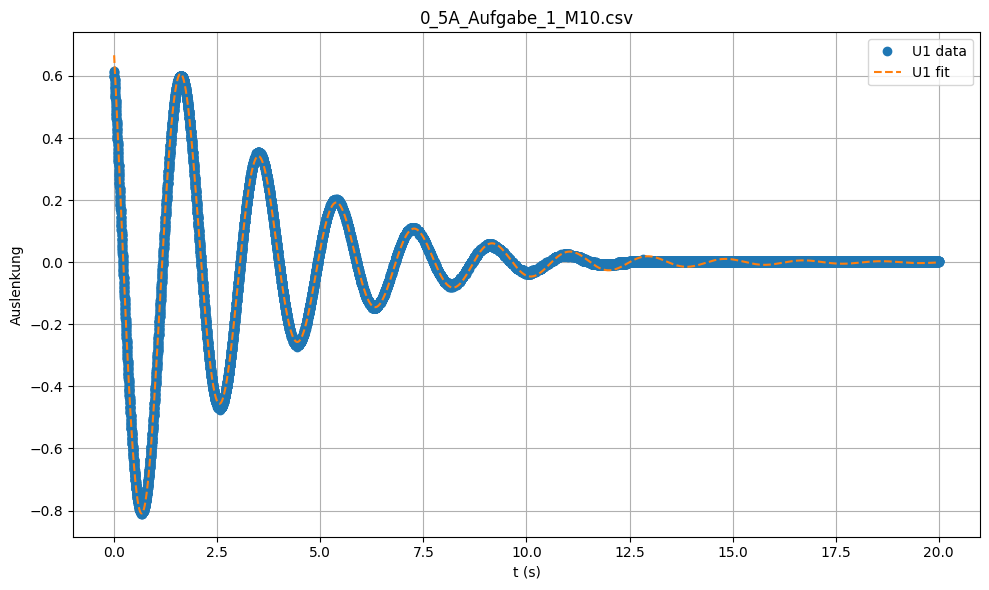

File: 0_6A_Aufgabe_1_M10.csv
Amplitude: 1.2813142499155765, Omega: 3.239165268880663, Delta: 0.4415399736691792, Phase: 0.4384944792838215, Offset: 0.0036579859582756193


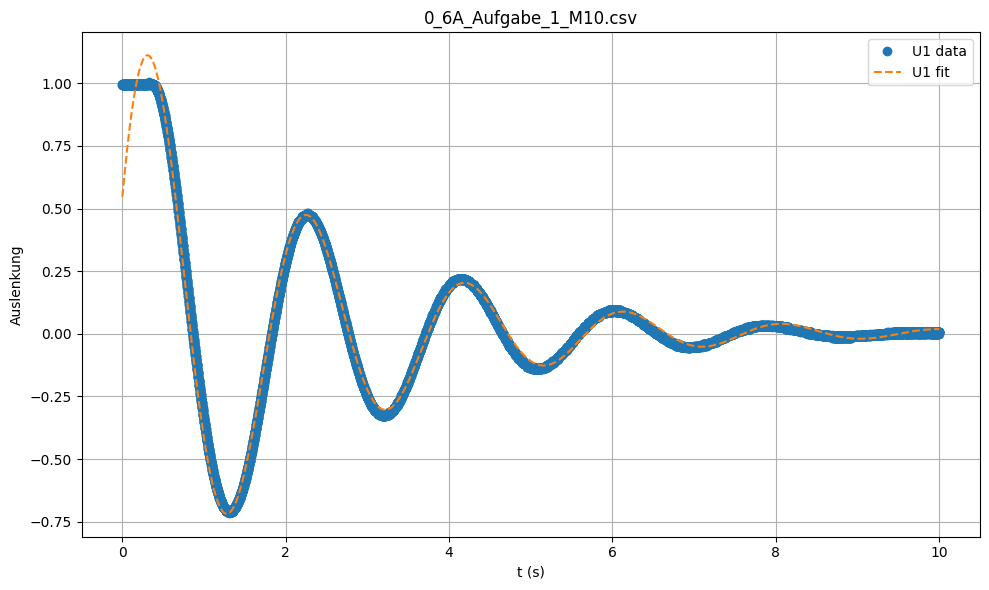

File: 0_7A_Aufgabe_1_M10.csv
Amplitude: 1.395042316341831, Omega: 3.1214365369505597, Delta: 0.5987119163434087, Phase: 0.38037785288273734, Offset: 0.007292143017511707


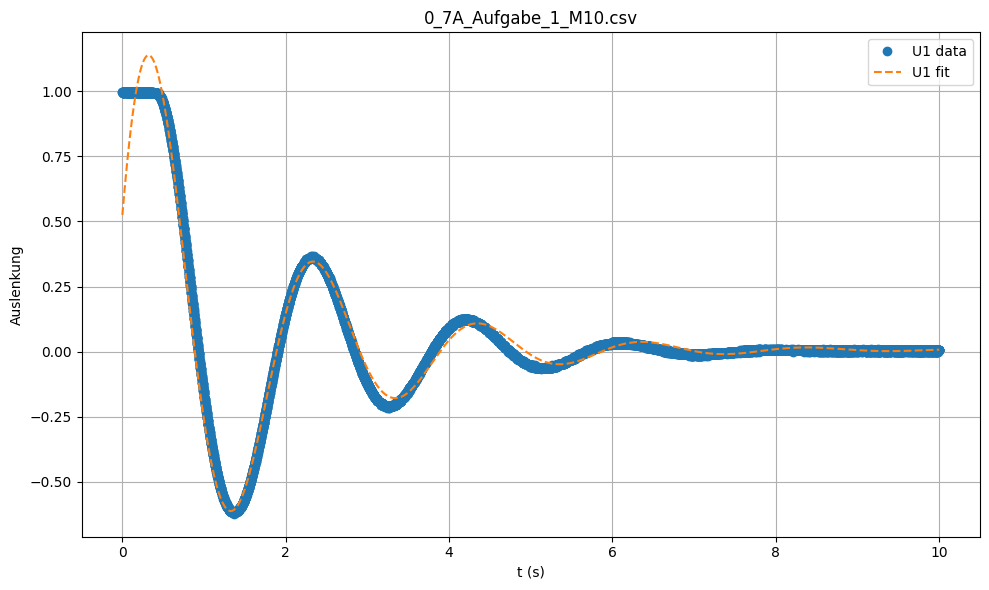

File: 0_8A_Aufgabe_1_M10.csv
Amplitude: 1.5785743774904772, Omega: 2.8732079876462535, Delta: 0.7636195933396239, Phase: 0.30744001844425384, Offset: 0.011371002528263893


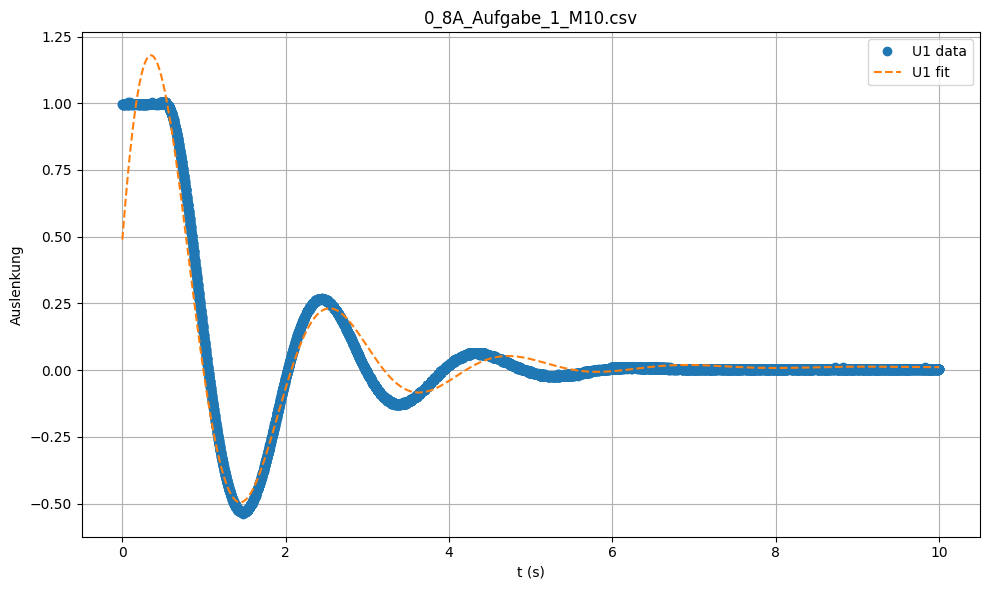

File: 0_9A_Aufgabe_1_M10.csv
Amplitude: 1.4480590066290961, Omega: 3.0023973512415103, Delta: 0.9086794767860934, Phase: 0.5034971845907589, Offset: 0.004513653581831536


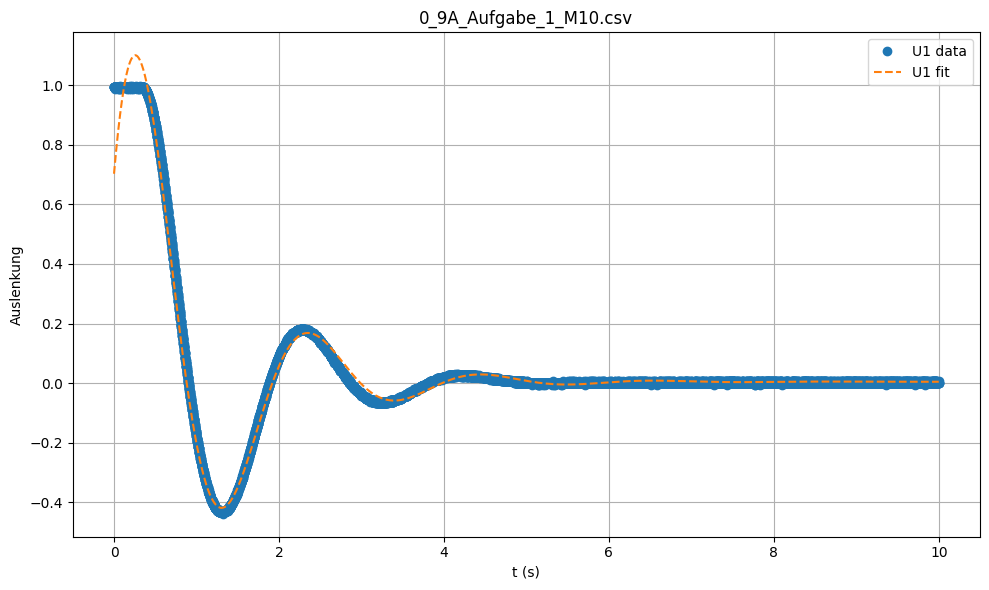

File: 1_0A_Aufgabe_1_M10.csv
Amplitude: 0.9745087305394624, Omega: 3.1352721230476823, Delta: 1.0937440970357062, Phase: 1.5549024058431256, Offset: 0.0038220298200599308


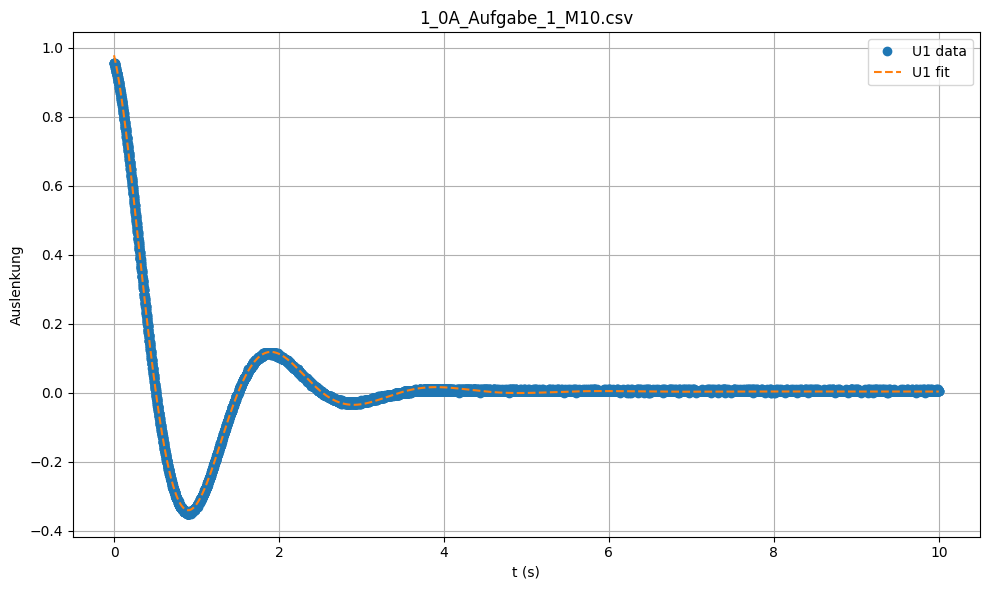

File: 1_1A_Aufgabe_1_M10.csv
Amplitude: 1.5538445837246633, Omega: 2.8438281769776337, Delta: 1.2780374990924965, Phase: 0.5461315750034915, Offset: 0.0034742730689521113


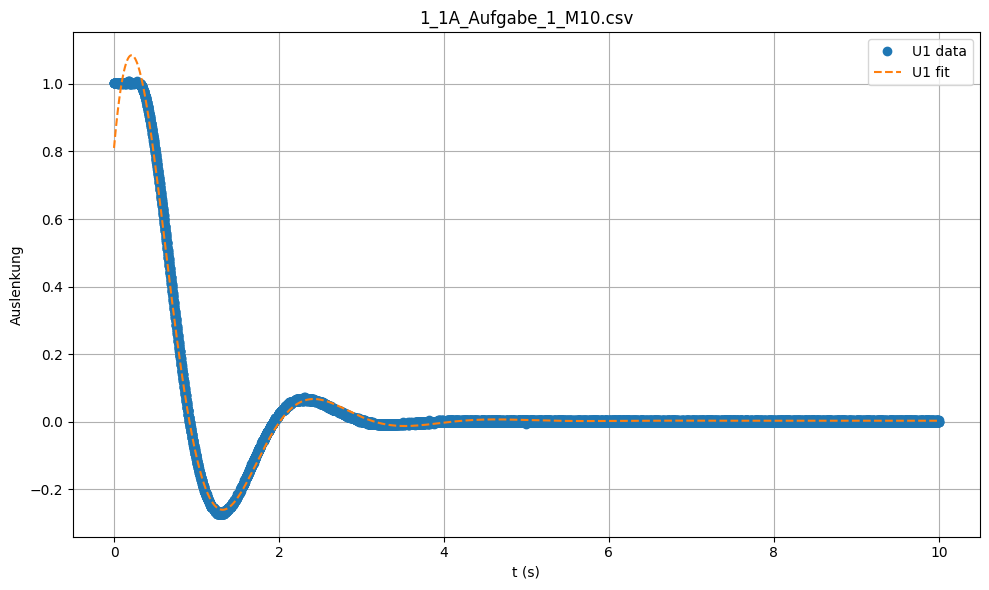

File: 1_2A_Aufgabe_1_M10.csv
Amplitude: 1.7047008426739967, Omega: 2.593157132174357, Delta: 1.420930108327294, Phase: 0.48342185808164584, Offset: 0.005639547584342991


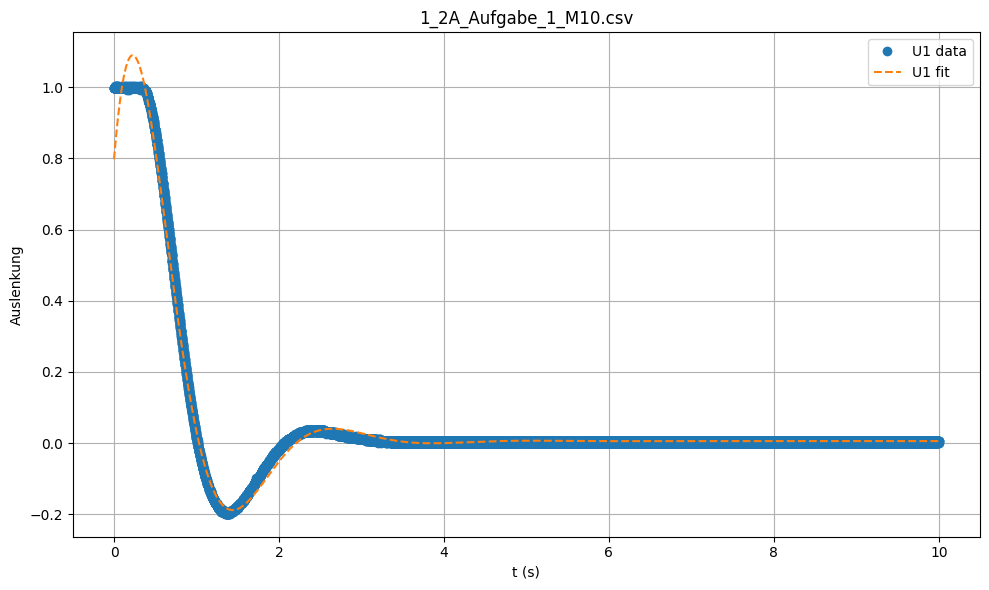

Tuple (Strom, Delta):
(0.3, np.float64(0.10043301779141933))
(0.4, np.float64(0.22370614583898954))
(0.5, np.float64(0.3039659026030872))
(0.6, np.float64(0.4415399736691792))
(0.7, np.float64(0.5987119163434087))
(0.8, np.float64(0.7636195933396239))
(0.9, np.float64(0.9086794767860934))
(1.0, np.float64(1.0937440970357062))
(1.1, np.float64(1.2780374990924965))
(1.2, np.float64(1.420930108327294))


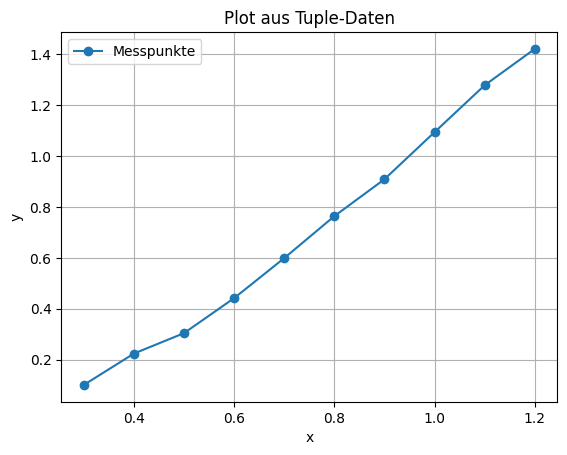

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import os
from natsort import natsorted
import re

def extract_numeric_prefix(filename):
    match = re.match(r"(\d+)_(\d+)", filename)
    if match:
        integer_part = match.group(1)
        decimal_part = match.group(2)
        return float(f"{integer_part}.{decimal_part}")
    return None


def damped_sinus_function(x, A, delta, omega, phase, offset):
    return A * np.exp(-delta * x) * np.sin(omega * x + phase) + offset


# Schätzfunktion für omega aus FFT
def estimate_omega_fft(x_data, y_data):
    dt = np.mean(np.diff(x_data))
    n = len(x_data)
    f = np.fft.fftfreq(n, d=dt)
    Y = np.fft.fft(y_data - np.mean(y_data))
    idx = np.argmax(np.abs(Y[1:n//2])) + 1  # überspringe 0-Frequenz
    freq = np.abs(f[idx])
    omega = 2 * np.pi * freq
    return omega

# Sinus fitten
def fit_damped_sinus(x_data, y_data):
    A_guess = (np.max(y_data) - np.min(y_data)) / 2
    omega_guess = estimate_omega_fft(x_data, y_data)
    delta_guess = 0.1  # Startwert für Dämpfung
    phase_guess = 0
    offset_guess = np.mean(y_data)
    p0 = [A_guess, delta_guess, omega_guess, phase_guess, offset_guess]
    
    params, params_covariance = curve_fit(
        damped_sinus_function, x_data, y_data, p0=p0, maxfev=10000
    )
    
    fitted_y = damped_sinus_function(x_data, *params)
    return params, fitted_y


# Ordnerpfad anpassen
filepath = "M10_Aufgabe_1_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]
csv_files = natsorted(csv_files)

# Listen für Amplituden und Omegas
amplitudes_U1 = []
omegas_U1 = []
tuple_delta_file = []

for filename in csv_files:
    df = pd.read_csv(os.path.join(filepath, filename))
    df = df[['t (s)', 'U1(V)']]  # Keep only the required columns

    x = df['t (s)'].values
    y = df['U1(V)'].values


    paramsU1, fitted_U1 = fit_damped_sinus(x, y)

    Strom = extract_numeric_prefix(filename)

    if Strom is not None:
        tuple_delta_file.append((Strom, paramsU1[1]))
    
    # Speichere absolute Amplitude (ohne Offset)
    amplitudes_U1.append(np.abs(paramsU1[0]))
    omegas_U1.append(paramsU1[1])

    print(f"File: {filename}")
    print(f"Amplitude: {np.abs(paramsU1[0])}, Omega: {paramsU1[2]}, Delta: {paramsU1[1]}, Phase: {paramsU1[3]}, Offset: {paramsU1[4]}")

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'o', label='U1 data')
    plt.plot(x, fitted_U1, '--', label='U1 fit')
    plt.xlabel('t (s)')
    plt.ylabel('Auslenkung')
    plt.title(filename)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("Tuple (Strom, Delta):")
for item in tuple_delta_file:
    print(item)
 
# Unpack the tuples into two separate lists
x_values, y_values = zip(*tuple_delta_file)

# Plot
plt.plot(x_values, y_values, 'o-', label='Messpunkte')
plt.xlabel('Ampere')
plt.ylabel('Delta')
plt.title('Plot aus Tuple-Daten')
plt.grid(True)
plt.legend()
plt.show()
